# Assignment 7
## Customer Segmentation using K-Means Clustering and PCA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

df=pd.read_csv('/mnt/data/Mall_Customers(1).csv')
print(df.head())
print(df.info())
print(df.describe())
print('Missing Values:\n',df.isnull().sum())
print('Numerical:',df.select_dtypes(include='number').columns.tolist())
print('Categorical:',df.select_dtypes(exclude='number').columns.tolist())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  

In [2]:
data=df.drop(columns=['CustomerID']).copy()
le=LabelEncoder()
data['Gender']=le.fit_transform(data['Gender'])
scaler=StandardScaler()
scaled=scaler.fit_transform(data)


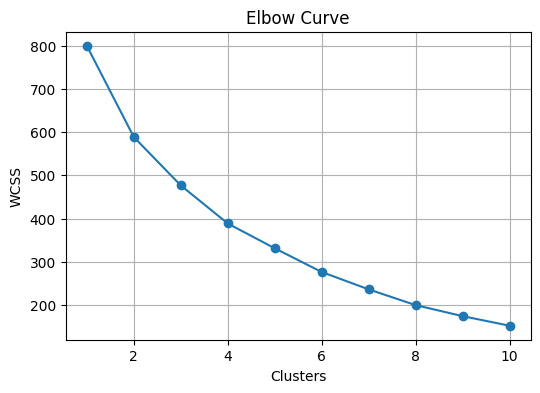

In [3]:
wcss=[]
for i in range(1,11):
    km=KMeans(n_clusters=i,random_state=42,n_init=10)
    km.fit(scaled)
    wcss.append(km.inertia_)
plt.figure(figsize=(6,4))
plt.plot(range(1,11),wcss,marker='o')
plt.title('Elbow Curve')
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

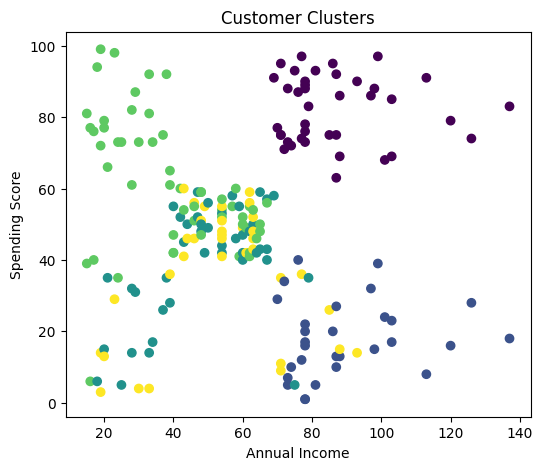

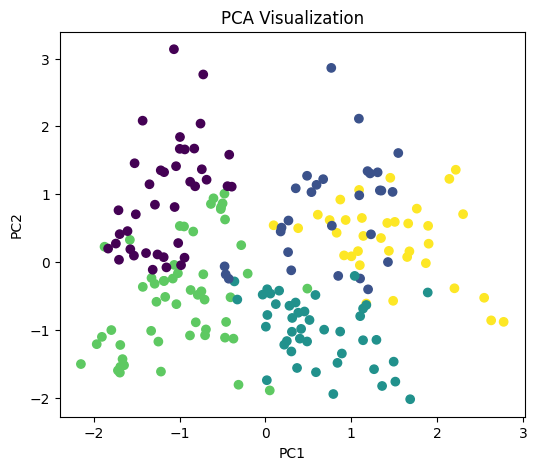

   Gender  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0       1   19                  15                      39        3
1       1   21                  15                      81        3
2       0   20                  16                       6        3
3       0   23                  16                      77        3
4       0   31                  17                      40        3


In [4]:
kmeans=KMeans(n_clusters=5,random_state=42,n_init=10)
labels=kmeans.fit_predict(scaled)
data['Cluster']=labels
pca=PCA(n_components=2)
pca_data=pca.fit_transform(scaled)
plt.figure(figsize=(6,5))
plt.scatter(data['Annual Income (k$)'],data['Spending Score (1-100)'],c=labels,cmap='viridis')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Clusters')
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(pca_data[:,0],pca_data[:,1],c=labels,cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Visualization')
plt.show()
print(data.head())

## Observations
1. The elbow curve suggests **5 clusters** as the optimal value.
2. PCA reduces the dataset to two dimensions while preserving most of the variance, making visualization easier.
3. The clusters represent customer groups with different income and spending patterns, which can support targeted marketing campaigns.

## Conclusion
K-Means clustering successfully segmented mall customers into five meaningful groups based on demographic and spending characteristics. PCA simplified the multi-feature dataset into two principal components, allowing clear visualization of customer clusters. These insights can help businesses design personalized marketing strategies, improve customer engagement, and optimize promotional campaigns. One limitation of K-Means is that the number of clusters must be chosen beforehand and the algorithm is sensitive to outliers. PCA is advantageous because it reduces dimensionality while retaining most of the important information, making complex datasets easier to analyze and interpret.